In [8]:
%pip install xmltodict

  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
Using cached xmltodict-1.0.4-py3-none-any.whl (13 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
# 데이터 요청 및 처리
import requests
import json
# 키 숨김처리
import os
from dotenv import load_dotenv
# XML을 딕셔너리로 바꿔주는 라이브러리
import xmltodict
# 시각화 세트
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [159]:
load_dotenv()
# 1. API 설정
serviceKey = os.getenv('DATA_GO_KR_API_KEY')
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"
params = {
    'serviceKey':serviceKey,
    'pageNo':'1',
    'numOfRows':'10000',
    'dataType':'XML',    
}
# 2. API 호출 및 JSON 파싱
response = requests.get(url, params=params)
dict_data = xmltodict.parse(response.content)
data_list = dict_data['response']['body']['items']['item']
# 3. DataFrame으로 변환
df_all = pd.DataFrame(data_list)
df_all.to_csv('EvCharger.csv', encoding='utf-8-sig', index=False)
# df_all.head()

In [103]:
df_all.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

1. 수집된 데이터의 shape과 실제 데이터 출력

In [161]:
df_all.shape

(10000, 37)

In [53]:
df_all

,statNm,statId,chgerId,chgerType,addr,addrDetail,location,lat,lng,useTime,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,null,null,37.476296,126.9583876,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,null,37.4536062,127.0428005,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,null,37.4918392,127.1178931,24시간 이용가능,...,None,N,None,N,None,N,2017,4,B,시그넷
3,현대자동차 수색대리점,ME174037,01,06,서울특별시 은평구 수색로 342-1,null,null,37.5867665,126.8880299,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
4,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,null,37.5718148,126.9850443,24시간 이용가능,...,None,N,None,N,None,N,2017,1,F,시그넷
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,부천시 공영주차장(법원 앞),BNBN0018,03,02,경기도 부천시 원미구 부일로237번길 41,부천시 공영주차장,부천시 공영주차장(법원 앞),37.490385800,126.75660210,24시간 이용가능,...,상황에 따라 변동,Y,상황에 따라 변동,N,None,N,2022,1,F,블루네트웍스
9995,부천시 공영주차장(법원 앞),BNBN0018,04,02,경기도 부천시 원미구 부일로237번길 41,부천시 공영주차장,부천시 공영주차장(법원 앞),37.490385800,126.75660210,24시간 이용가능,...,상황에 따라 변동,Y,상황에 따라 변동,N,None,N,2022,1,F,블루네트웍스
9996,시흥 목감119안전센터,BNBN0021,01,02,"경기 시흥시 목감우회로 15 (조남동, 목감119안전센터)",null,null,37.3813757,126.8576483,24시간 이용가능,...,시설 상황에 따라 제한 될 수 있음,N,시설 상황에 따라 이용이 제한될 수 있음,N,None,N,2022,1,F,블루네트웍스
9997,전남 나주 한국콘텐츠진흥원,BNBN0023,01,04,"전남 나주시 교육길 35 (빛가람동, 한국콘텐츠진흥원)",null,null,35.0194349,126.7819033,0000~0000,...,None,N,시설 상황에 따라 이용이 제할될 수 있음,N,None,N,2021,1,F,블루네트웍스


2. 분석에 필요한 핵심 컬럼만 선택

In [163]:
# statNm: 충전소명, addr: 주소, chgerType: 충전기 타입, useTime: 이용시간
column_map = {
    'statNm': '충전소명',
    'addr': '주소',
    'chgerType': '충전기 타입',
    'useTime': '이용시간'    
}
df_all = pd.read_csv('EvCharger.csv')
df = df_all[['statNm','addr','chgerType','useTime']]
display(df.rename(columns=column_map).head())

,충전소명,주소,충전기 타입,이용시간
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


In [109]:
df.shape

(10000, 4)

3. 결측치(NaN) 확인 및 처리

In [165]:
# 결측치 확인
df.isnull().sum()

statNm       0
addr         0
chgerType    0
useTime      5
dtype: int64

In [167]:
# 결측치 제거
df.dropna(inplace=True)

/var/folders/7_/1dlclw_s1xl9dpcn_pv3hzg00000gn/T/ipykernel_83067/2874132784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

In [117]:
# 1. 중복 확인
# 'keep=False'로 설정하면 중복된 모든 행(원본+복사본 전체)을 보여줍니다.
duplicate_rows = df[df.duplicated(subset=['statNm', 'addr'], keep=False)]

# 결과 확인 (정렬해서 보면 중복 데이터끼리 모여서 보기 편합니다)
display(duplicate_rows.sort_values(by=['statNm', 'addr']))

,statNm,addr,chgerType,useTime
1311,(구)거진수산센터 주차장,강원특별자치도 고성군 거진읍 거진리 22-93,4,24시간 이용가능
1312,(구)거진수산센터 주차장,강원특별자치도 고성군 거진읍 거진리 22-93,4,24시간 이용가능
4008,(재)강원테크노파크,강원특별자치도 춘천시 신북읍 61-10,4,24시간 이용가능
4009,(재)강원테크노파크,강원특별자치도 춘천시 신북읍 61-10,4,24시간 이용가능
6522,(재)군산먹거리통합지원센터,전북특별자치도 군산시 성산면 창오리 560-2,4,24시간 이용가능
...,...,...,...,...
8071,흥부생활체육공원,경상북도 울진군 북면 남산길 154,4,24시간 이용가능
7479,흥해파출소,경상북도 포항시 북구 흥해읍 흥해로 78,4,24시간 이용가능
7480,흥해파출소,경상북도 포항시 북구 흥해읍 흥해로 78,4,24시간 이용가능
5211,힐링사업소(와인터널주차장),충청북도 영동군 영동읍 매천리 165,4,24시간 이용가능


In [169]:
# 2. 중복 제거
# 방법 1: 충전소 이름과 주소가 모두 같아야 '진짜 같은 곳'으로 판정
df_unique = df.drop_duplicates(subset=['statNm', 'addr'], keep='first').copy()
df_unique.head()
# 방법 2: 가장 정확한 방법 (이름 + 위도 + 경도)
# 휴게소 상/하행은 위도(lat), 경도(lng)가 반드시 다르기 때문에 살아남습니다.
# df_unique = df.drop_duplicates(subset=['statNm', 'lat', 'lng'], keep='first')

,statNm,addr,chgerType,useTime
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능


In [171]:
df_unique.shape

(5159, 4)

In [157]:
df_unique.columns

Index(['statNm', 'addr', 'chgerType', 'useTime', 'sido', 'type_nm', 'is_24h'], dtype='object')

## 특성공학
1. 주소 데이터에서 '시/도' 파생 변수 생성

In [173]:
# 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df_unique['sido'] = df_unique['addr'].str.split().str[0]
df_unique.head()

,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울특별시
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울특별시
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울특별시
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울특별시
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울특별시


In [179]:
# 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
df_unique['sido'] = df_unique['sido'].str[:2]
df_unique.head(3)

,statNm,addr,chgerType,useTime,sido
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울


In [181]:
df_unique['sido'].value_counts()

sido
경상    1162
충청     753
경기     714
전라     503
강원     423
전북     406
제주     220
서울     180
인천     171
대구     145
대전     117
광주     114
울산     113
부산      87
세종      45
충남       2
전남       2
경북       1
충북       1
Name: count, dtype: int64

In [187]:
# 특정 그룹들을 하나로 통합
df_unique['sido'] = df_unique['sido'].replace({
    '충남': '충청', '충북': '충청',
    '전남': '전라', '전북': '전라',
    '경남': '경상', '경북': '경상'
})
df_unique['sido'].value_counts()

sido
경상    1163
전라     911
충청     756
경기     714
강원     423
제주     220
서울     180
인천     171
대구     145
대전     117
광주     114
울산     113
부산      87
세종      45
Name: count, dtype: int64

2. 충전기 타입 범주화 (Mapping)

In [189]:
df_unique.shape

(5159, 5)

In [191]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['chgerType'].value_counts()

chgerType
4     3758
6     1202
2      146
10      46
11       2
5        2
8        1
7        1
1        1
Name: count, dtype: int64

In [193]:
# API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) 
# : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
# API 코드값을 텍스트로 치환
type_map = {1: '완속', 3: '급속', 6: '초급속'}
df_unique['type_nm'] = df_unique['chgerType'].map(type_map).fillna('기타')
df_unique.head()

,statNm,addr,chgerType,useTime,sido,type_nm
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울,초급속
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울,초급속
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울,초급속
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울,초급속
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울,초급속


3. 24시간 이용 가능 여부 파생 변수 생성

In [195]:
# 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
# '24시간' 글자가 포함되어 있으면 True
df_unique['is_24h'] = df_unique['useTime'].str.contains('24시간')
df_unique.head()

,statNm,addr,chgerType,useTime,sido,type_nm,is_24h
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,서울,초급속,True
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,서울,초급속,True
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,서울,초급속,True
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,서울,초급속,True
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,서울,초급속,True


In [197]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['is_24h'].value_counts()

is_24h
True     4785
False     374
Name: count, dtype: int64

In [199]:
df_unique.to_csv('EvCharger_Preprocessing.csv', encoding='utf-8-sig', index=False)

## 📊 시각화
- 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
- 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
- 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

In [201]:
# 빈도수 확인 (내림차순 정렬됨)
df_unique['sido'].value_counts()

sido
경상    1163
전라     911
충청     756
경기     714
강원     423
제주     220
서울     180
인천     171
대구     145
대전     117
광주     114
울산     113
부산      87
세종      45
Name: count, dtype: int64

<Axes: xlabel='sido', ylabel='count'>

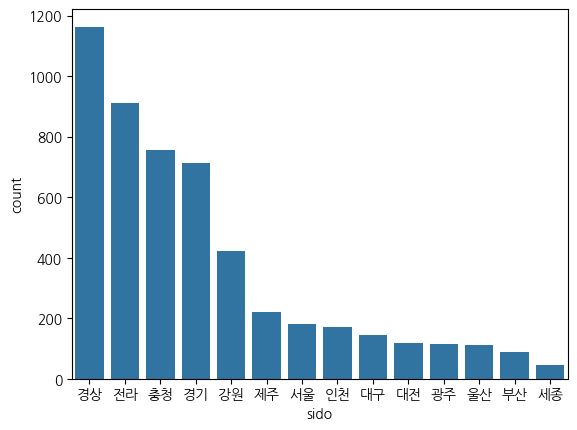

In [203]:
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)
sns.countplot(data=df_unique, x='sido', order=df_unique['sido'].value_counts().index)

In [215]:
df_unique['type_nm'].value_counts()

type_nm
기타     3956
초급속    1202
완속        1
Name: count, dtype: int64

<Axes: ylabel='count'>

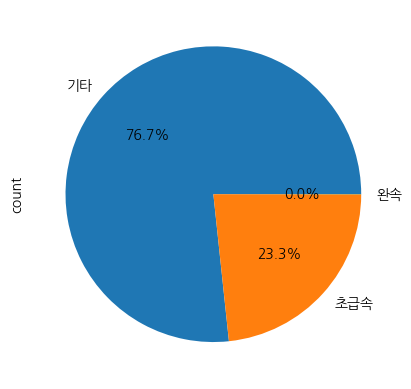

In [205]:
# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)
df_unique['type_nm'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: xlabel='sido', ylabel='count'>

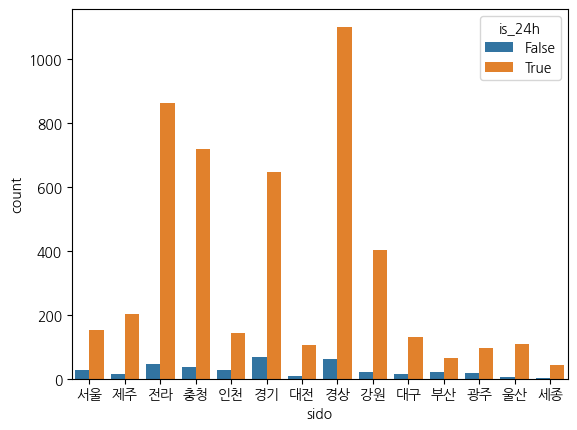

In [207]:
# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)
# Countplot hue 사용
sns.countplot(data=df_unique, x='sido', hue='is_24h')

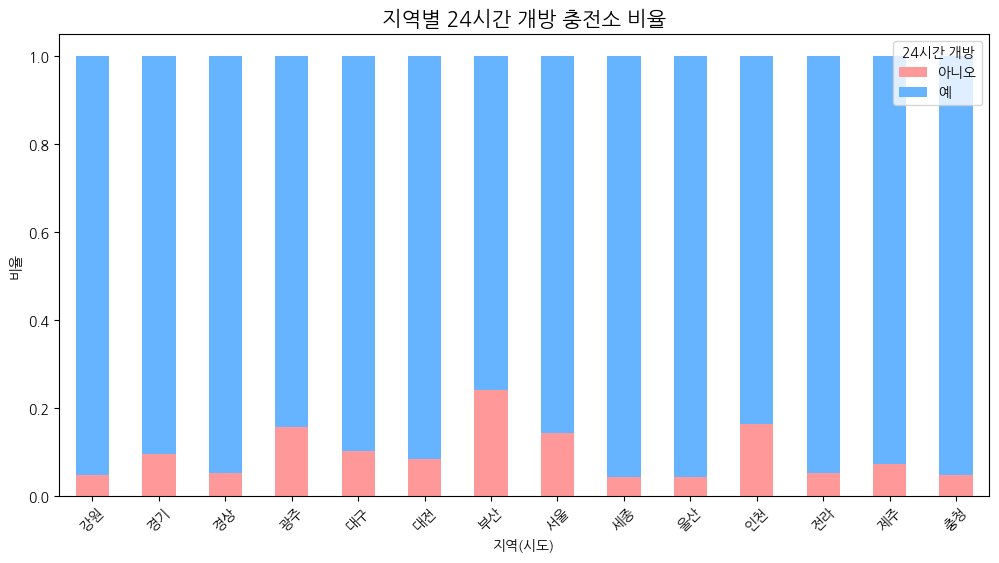

In [209]:
# Stacked Bar Chart 사용
# 1. 시도별 24시간 여부 교차표 생성
ct = pd.crosstab(df_unique['sido'], df_unique['is_24h'])

# 2. 비율로 변환 (각 행의 합으로 나눔) -> 0~1 사이 값
ct_pct = ct.div(ct.sum(1), axis=0)

# 3. 시각화
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])

plt.title('지역별 24시간 개방 충전소 비율', fontsize=15)
plt.xlabel('지역(시도)')
plt.ylabel('비율')
plt.legend(title='24시간 개방', labels=['아니오', '예'], loc='upper right')
plt.xticks(rotation=45)
plt.show()

In [211]:
df_unique['is_24h'].value_counts()

is_24h
True     4785
False     374
Name: count, dtype: int64

<Axes: >

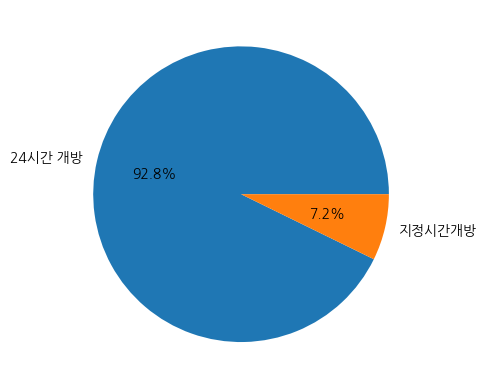

In [213]:
# 비율 확인
df_unique['is_24h'].value_counts().rename({True: '24시간 개방', False: '지정시간개방'}).plot.pie(autopct='%1.1f%%', ylabel='')

## 도출 인사이트

In [ ]:
인프라 집중도 : 경상도, 전라도, 충청도 순으로 인프라 집중도가 좋은편으로 보이나 면적이 넓어서 일수도 있다
기술 트랜드 : 기타가 77%정도라서 판단하기 힘들지만 초급속 23%정도를 차지하고 있다
편의성 : 24시간개방이 93%이상으로 매우 편의성이 좋은것으로 보임